In [8]:
import sys, os

In [9]:
sys.path.append(os.path.abspath(".."))

In [10]:
import yfinance as yf

In [11]:
import equitytools_local.data

In [12]:
from equitytools_local.data import load_price_data

In [46]:
import matplotlib.pyplot as plt

In [30]:
#ticker_symbol = "SCHD"  # Schwab US Dividend ETF

In [79]:
ticker_symbol = "IEUR" #  Euro Fund

In [80]:
etf = yf.Ticker(ticker_symbol)

In [81]:
equities = etf.funds_data.top_holdings

In [82]:
print (equities)

                                  Name  Holding Percent
Symbol                                                 
ASML.AS                ASML Holding NV         0.035369
ROG.SW                Roche Holding AG         0.020161
HSBA.L               HSBC Holdings PLC         0.019173
AZN.L                  AstraZeneca PLC         0.018196
NOVN.SW  Novartis AG Registered Shares         0.017796
NESN.SW                      Nestle SA         0.015468
SIE.DE                      Siemens AG         0.014612
SHEL.L                       Shell PLC         0.014028
SAP.DE                          SAP SE         0.013336
SAN.MC              Banco Santander SA         0.012042


In [83]:
equities = equities.reset_index()

In [84]:
labels = equities["Symbol"]

In [85]:
sizes = equities["Holding Percent"]

In [86]:
def plotHoldings(sizes, labels):
    plt.figure(figsize=(8,8))
    plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=140,
    pctdistance=0.85
    )
    plt.title(f"{ticker_symbol} Equity Holdings")
    plt.tight_layout()
    plt.show()

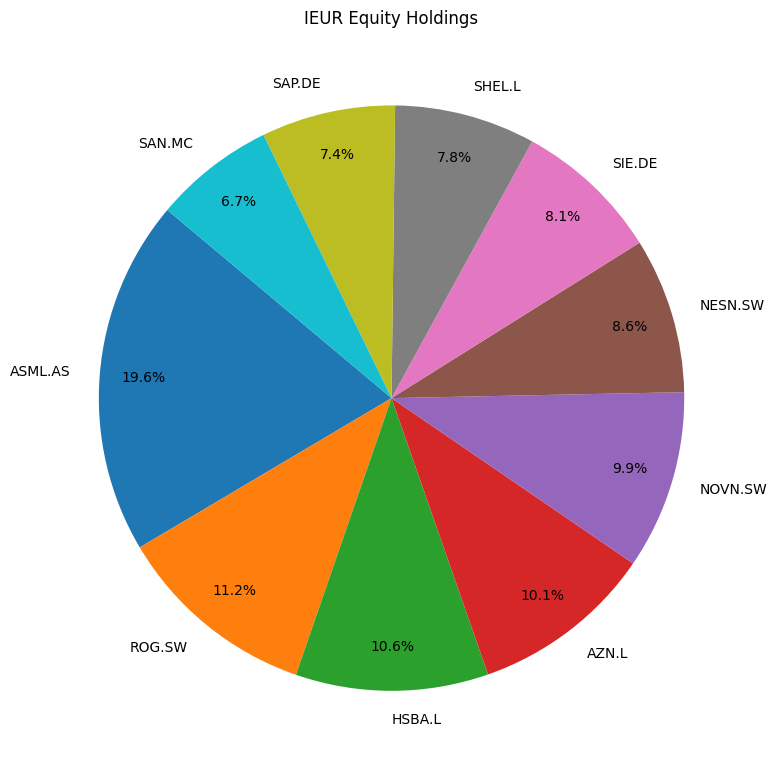

In [87]:
plotHoldings(sizes, labels)

In [88]:
sectors = etf.funds_data.sector_weightings

In [89]:
print (sectors)

{'realestate': 0.0165, 'consumer_cyclical': 0.075500004, 'basic_materials': 0.0553, 'consumer_defensive': 0.083500005, 'technology': 0.0806, 'communication_services': 0.0359, 'financial_services': 0.2288, 'utilities': 0.0444, 'industrials': 0.2041, 'energy': 0.0423, 'healthcare': 0.13319999}


In [90]:
labels2 = list(sectors.keys())
sizes2 = list(sectors.values())

In [91]:
def plotSecors(sizes, labels):
    fig, ax = plt.subplots(figsize=(8, 8))
    wedges, texts, autotexts = ax.pie(
        sizes,
        labels=labels,
        autopct='%1.1f%%',  # Show percentage
        startangle=140,     # Rotate start
        shadow=True,        # Add shadow
        wedgeprops={'edgecolor': 'black'}
    )
    
    # Improve text appearance
    for text in texts:
        text.set_fontsize(10)
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontsize(9)
    
    # Equal aspect ratio ensures pie is drawn as a circle
    ax.axis('equal')
    plt.title("Sector Allocation", fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    # Show chart
    plt.show()


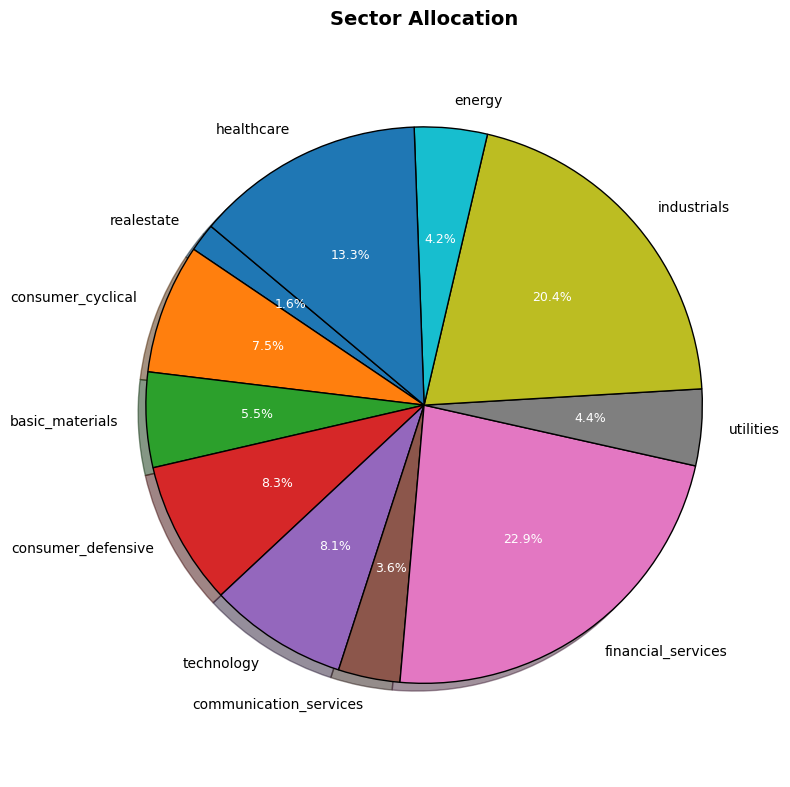

In [92]:
plotSecors(sizes2, labels2)